<a href="https://colab.research.google.com/github/BrunoMog/PROJETOS-IF687/blob/main/mlp_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
from sklearn.datasets import load_iris
from torch.utils.data import DataLoader
from torch import nn
from sklearn.model_selection import train_test_split
import sklearn.metrics as metrics
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import optuna
from fvcore.nn import FlopCountAnalysis
from functools import partial
from plotly.io import show
import numpy as np

## Códigos para dataset

In [ ]:
# definindo a classe responsável por criar o dataset no formato do pytorch
class CustomIrisDataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        # deve retornar o target no formato 
        return self.X[idx], self.y[idx]

In [ ]:
def iris_dataset():
    # carregando o dataset iris e dividindo em treino e teste
    iris = load_iris()
    X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.2, random_state=96, stratify=iris.target)
    # criar um conjunto de validação a partir do conjunto de treino
    X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=52, stratify=y_train)

    print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}, X_val shape: {X_val.shape}")

    # criando os datasets de treino e teste
    train_data = CustomIrisDataset(X_train, y_train)
    test_data = CustomIrisDataset(X_test, y_test)
    val_data = CustomIrisDataset(X_val, y_val)
    return train_data, test_data, val_data

## Códigos para criação da rede, treinamento, e otimização de hiperparâmetros

In [ ]:
# criando a classe genérica do modelo MLP que recebe como entradao o número de camadas, o número de neurônios por camada e a função de ativação
# o número de camadas é dado pelo tamanho da lista hidden_layers, onde cada elemento representa o número de neurônios daquela camada
class MLP(nn.Module):
    def __init__(self, input_size, hidden_layers, output_size, activation_fn):
        super(MLP, self).__init__()
        layers = []
        in_features = input_size

        for hidden_layer in hidden_layers:
            layers.append(nn.Linear(in_features, hidden_layer))
            layers.append(activation_fn())
            in_features = hidden_layer

        layers.append(nn.Linear(in_features, output_size))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        logits = self.model(x)
        return logits

In [ ]:
# função para criação do modelo, e definição dos hiperparâmetros do modelo e dataloaders
def create_model_and_dataloaders(input_size, hidden_layers, output_size, activation_fn, train_data, test_data, val_data, batch_size):
    model = MLP(input_size, hidden_layers, output_size, activation_fn)
    train_dataloader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    test_dataloader = DataLoader(test_data, batch_size=batch_size, shuffle=False)
    val_dataloader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
    return model, train_dataloader, test_dataloader, val_dataloader

In [ ]:
# função para avaliar o modelo no conjunto de teste
def evaluate_model(model, test_dataloader, metric_fn=metrics.accuracy_score):
    model.eval()
    y = []
    y_pred = []
    with torch.no_grad():
        for X_batch, y_batch in test_dataloader:
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)
            y.extend(y_batch.tolist())
            y_pred.extend(predicted.tolist())
    metric_val = metric_fn(y, y_pred)
    return metric_val

In [ ]:
# função para treinar o modelo, recebe como entrada o modelo, os dataloaders de treino e validação, a função de perda, o otimizador e o número de épocas e o critério de parada
# a função também salva o histórico da função de perda para treino e validação
def train_model(model, train_dataloader, val_dataloader, loss_fn, optimizer, num_epochs, patience, metric_fn=None):
    best_val_loss = float('inf')
    epochs_without_improvement = 0
    history_train_loss = []
    history_val_loss = []
    history_val_metric = []

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0

        for X_batch, y_batch in train_dataloader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = loss_fn(outputs, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_dataloader)
        history_train_loss.append(avg_train_loss)

        # validação
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_dataloader:
                outputs = model(X_batch)
                loss = loss_fn(outputs, y_batch)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_dataloader)
        history_val_loss.append(avg_val_loss)

        # avaliando a métrica de validação
        if metric_fn is not None:
            metric_val = evaluate_model(model, val_dataloader, metric_fn=metric_fn)
            history_val_metric.append(metric_val)

        # critério de parada
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            break

    return history_train_loss, history_val_loss, history_val_metric


In [ ]:
# função para otimização de hiperparâmetros usando optuna
def objective(trial, train_data, test_data, val_data, metric_fn=None, optimizer_fn=torch.optim.Adam, optimizer_params=None):
    # definindo os hiperparâmetros a serem otimizados
    n_layers = trial.suggest_int("n_layers", 1, 3)
    hidden_layers = []
    for i in range(n_layers):
        units = trial.suggest_int(f"n_units_l{i}", 1, 10, step=1)
        hidden_layers.append(units)
    activation_name = trial.suggest_categorical("activation_fn", ["relu", "tanh", "sigmoid"])
    activation_map = {
    "relu": nn.ReLU,
    "tanh": nn.Tanh,
    "sigmoid": nn.Sigmoid,
    }
    activation_fn = activation_map[activation_name]
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-1, log=True)
    batch_size = trial.suggest_categorical('batch_size', [8, 16, 32])

    params = (4, hidden_layers, 3, activation_fn, train_data, test_data, val_data, batch_size)

    model, train_dataloader, test_dataloader, val_dataloader = create_model_and_dataloaders(*params)

    # definindo a função de perda e o otimizador
    loss_fn = nn.CrossEntropyLoss()
    optimizer = optimizer_fn(model.parameters(), lr=learning_rate, **(optimizer_params or {}))

    # treinando o modelo
    params = (model, train_dataloader, val_dataloader, loss_fn, optimizer, 100000, 50, metric_fn)
    history_train_loss, history_val_loss, history_val_metric = train_model(*params)


    flops = FlopCountAnalysis(model, inputs=(torch.randn(1, 4),)).total()
    return history_val_metric[-1], flops


## Execução da otimização de hiperparâmetros

In [ ]:
train_data, test_data, val_data = iris_dataset()

objective_wrapped = partial(
    objective,
    train_data=train_data,
    test_data=test_data,
    val_data=val_data,
    metric_fn=metrics.accuracy_score,
    optimizer_fn=torch.optim.Adam
)

study = optuna.create_study(directions=['maximize', 'minimize'])

study.optimize(objective_wrapped, n_trials=300)



[I 2026-04-03 23:47:38,564] A new study created in memory with name: no-name-9ba5862b-a365-4562-ba22-0f517df97c87


X_train shape: (96, 4), X_test shape: (30, 4), X_val shape: (24, 4)


Unsupported operator aten::tanh encountered 2 time(s)
[I 2026-04-03 23:47:45,439] Trial 0 finished with values: [0.9583333333333334, 132.0] and parameters: {'n_layers': 2, 'n_units_l0': 9, 'n_units_l1': 8, 'activation_fn': 'tanh', 'learning_rate': 0.0005658149356107846, 'batch_size': 32}.
Unsupported operator aten::sigmoid encountered 2 time(s)
[I 2026-04-03 23:47:47,154] Trial 1 finished with values: [0.9583333333333334, 33.0] and parameters: {'n_layers': 2, 'n_units_l0': 2, 'n_units_l1': 5, 'activation_fn': 'sigmoid', 'learning_rate': 0.027536564513813647, 'batch_size': 16}.
Unsupported operator aten::sigmoid encountered 3 time(s)
[I 2026-04-03 23:48:32,424] Trial 2 finished with values: [0.6666666666666666, 62.0] and parameters: {'n_layers': 3, 'n_units_l0': 2, 'n_units_l1': 7, 'n_units_l2': 4, 'activation_fn': 'sigmoid', 'learning_rate': 0.0002222362477584482, 'batch_size': 16}.
[I 2026-04-03 23:48:35,317] Trial 3 finished with values: [0.9583333333333334, 131.0] and parameters: {'

In [ ]:

print("Number of finished trials: ", len(study.trials))

print("Pareto front:")

trials = sorted(study.best_trials, key=lambda t: t.values[0] > 0.9)

for trial in trials:
    print("  Trial#{}".format(trial.number))
    print("    Values: FLOPS={}, accuracy={}".format(trial.values[1], trial.values[0]))
    print("    Params: {}".format(trial.params))

Number of finished trials:  300
Pareto front:
  Trial#129
    Values: FLOPS=7.0, accuracy=0.9583333333333334
    Params: {'n_layers': 1, 'n_units_l0': 1, 'activation_fn': 'sigmoid', 'learning_rate': 0.042234456147942044, 'batch_size': 16}
  Trial#132
    Values: FLOPS=14.0, accuracy=1.0
    Params: {'n_layers': 1, 'n_units_l0': 2, 'activation_fn': 'tanh', 'learning_rate': 0.042234456147942044, 'batch_size': 32}
  Trial#156
    Values: FLOPS=7.0, accuracy=0.9583333333333334
    Params: {'n_layers': 1, 'n_units_l0': 1, 'activation_fn': 'sigmoid', 'learning_rate': 0.042234456147942044, 'batch_size': 16}
  Trial#211
    Values: FLOPS=14.0, accuracy=1.0
    Params: {'n_layers': 1, 'n_units_l0': 2, 'activation_fn': 'sigmoid', 'learning_rate': 0.0005833273696919411, 'batch_size': 16}
  Trial#256
    Values: FLOPS=7.0, accuracy=0.9583333333333334
    Params: {'n_layers': 1, 'n_units_l0': 1, 'activation_fn': 'sigmoid', 'learning_rate': 0.03262140091862391, 'batch_size': 32}
  Trial#274
    Valu

## Treinamento do melhor modelo encontrado, e plots

In [ ]:
fig = optuna.visualization.plot_param_importances(study, target=lambda t: t.values[0], target_name="accuracy")
show(fig)

In [ ]:
fig = optuna.visualization.plot_pareto_front(study, target_names=["accuracy", "FLOPS"])
show(fig)

Best trial parameters: {'n_layers': 1, 'n_units_l0': 1, 'activation_fn': 'sigmoid', 'learning_rate': 0.042234456147942044, 'batch_size': 16}


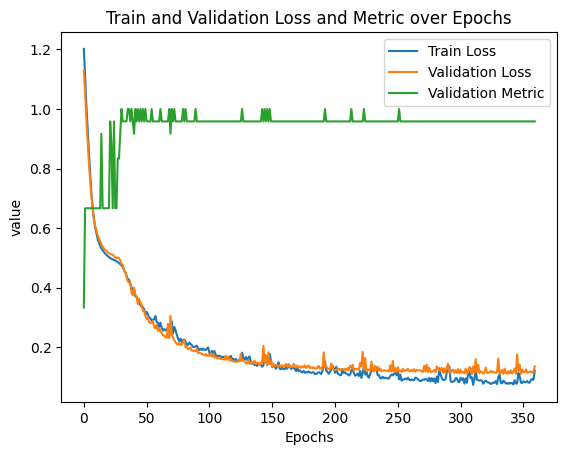

In [ ]:

# função para plotar o gráfico de perda para treino e validação do melhor modelo encontrado
def plot_loss_graph(history_train_loss, history_val_loss, history_val_metric):
    plt.plot(history_train_loss, label='Train Loss')
    plt.plot(history_val_loss, label='Validation Loss')
    plt.plot(history_val_metric, label='Validation Metric')
    plt.xlabel('Epochs')
    plt.ylabel('value')
    plt.title('Train and Validation Loss and Metric over Epochs')
    plt.legend()
    plt.show()


best_trial = trials[0]
best_params = best_trial.params
print(f"Best trial parameters: {best_params}")

activation_map = {
"relu": nn.ReLU,
"tanh": nn.Tanh,
"sigmoid": nn.Sigmoid,
}

params = (4, [best_params[f"n_units_l{i}"] for i in range(best_params["n_layers"])], 3, activation_map[best_params["activation_fn"]], train_data, test_data, val_data, best_params["batch_size"])
best_model, train_dataloader, test_dataloader, val_dataloader = create_model_and_dataloaders(*params)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(best_model.parameters(), lr=best_params["learning_rate"])
params = (best_model, train_dataloader, val_dataloader, loss_fn, optimizer, 100000, 50, metrics.accuracy_score)
history_train_loss, history_val_loss, history_val_metric = train_model(*params)

plot_loss_graph(history_train_loss, history_val_loss, history_val_metric)


In [ ]:
print(best_model)

MLP(
  (model): Sequential(
    (0): Linear(in_features=4, out_features=1, bias=True)
    (1): Sigmoid()
    (2): Linear(in_features=1, out_features=3, bias=True)
  )
)


In [ ]:
evaluate_model(best_model, test_dataloader, metric_fn=metrics.accuracy_score)

1.0

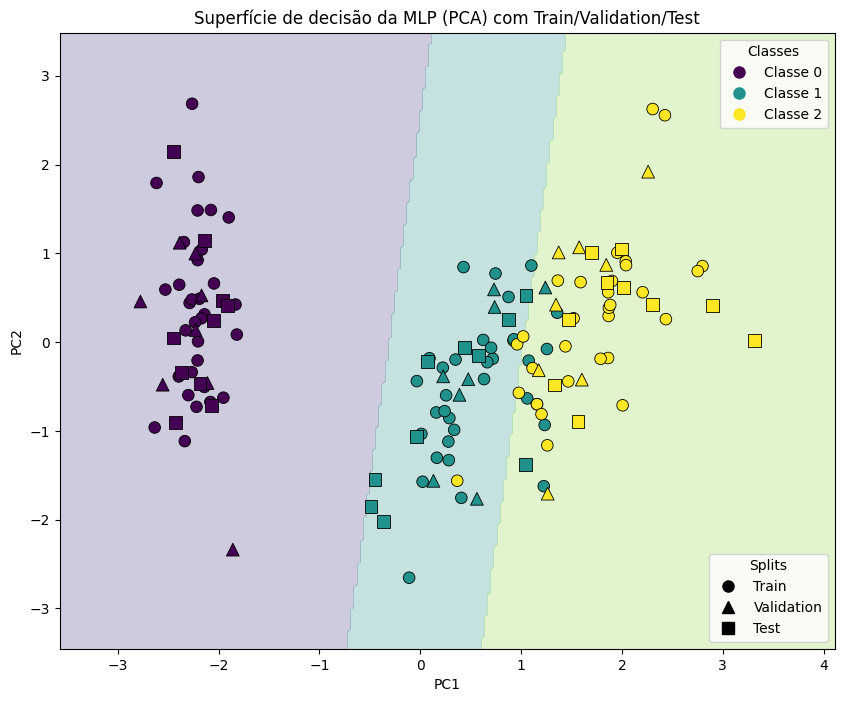

In [ ]:

def _dataset_to_numpy(dataset):
    X = dataset.X.detach().cpu().numpy().astype(np.float32)
    y = dataset.y.detach().cpu().numpy().astype(np.int64)
    return X, y


def plot_decision_surface_with_splits_pca(model, train_data, val_data, test_data, grid_resolution=250, pad=0.8):
    """
    Plota a superfície de decisão de um modelo treinado em 4D,
    projetando os dados para 2D com PCA e destacando os splits.
    """
    model.eval()

    X_train, y_train = _dataset_to_numpy(train_data)
    X_val, y_val = _dataset_to_numpy(val_data)
    X_test, y_test = _dataset_to_numpy(test_data)

    # Mantém a mesma distribuição usada no experimento (train/val/test).
    X_all = np.vstack([X_train, X_val, X_test])

    scaler = StandardScaler()
    X_all_std = scaler.fit_transform(X_all)

    pca = PCA(n_components=2, random_state=42)
    X_all_pca = pca.fit_transform(X_all_std)

    n_train = len(X_train)
    n_val = len(X_val)
    X_train_pca = X_all_pca[:n_train]
    X_val_pca = X_all_pca[n_train:n_train + n_val]
    X_test_pca = X_all_pca[n_train + n_val:]

    x_min, x_max = X_all_pca[:, 0].min() - pad, X_all_pca[:, 0].max() + pad
    y_min, y_max = X_all_pca[:, 1].min() - pad, X_all_pca[:, 1].max() + pad

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, grid_resolution),
        np.linspace(y_min, y_max, grid_resolution)
    )

    grid_pca = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
    grid_std_4d = pca.inverse_transform(grid_pca)
    grid_4d = scaler.inverse_transform(grid_std_4d).astype(np.float32)

    with torch.no_grad():
        logits = model(torch.tensor(grid_4d, dtype=torch.float32))
        preds = torch.argmax(logits, dim=1).cpu().numpy()

    Z = preds.reshape(xx.shape)

    cmap = plt.cm.viridis
    norm = plt.Normalize(vmin=0, vmax=2)

    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, alpha=0.26, levels=np.arange(-0.5, 3.5, 1), cmap=cmap)

    plt.scatter(
        X_train_pca[:, 0], X_train_pca[:, 1],
        c=y_train, cmap=cmap, norm=norm,
        marker='o', s=70, edgecolor='k', linewidth=0.6,
        label='Train'
    )

    plt.scatter(
        X_val_pca[:, 0], X_val_pca[:, 1],
        c=y_val, cmap=cmap, norm=norm,
        marker='^', s=85, edgecolor='k', linewidth=0.6,
        label='Validation'
    )

    plt.scatter(
        X_test_pca[:, 0], X_test_pca[:, 1],
        c=y_test, cmap=cmap, norm=norm,
        marker='s', s=85, edgecolor='k', linewidth=0.6,
        label='Test'
    )

    class_handles = [
        plt.Line2D([], [], marker='o', linestyle='', color=cmap(norm(i)), markersize=8, label=f'Classe {i}')
        for i in np.unique(np.concatenate([y_train, y_val, y_test]))
    ]
    split_handles = [
        plt.Line2D([], [], marker='o', linestyle='', color='black', markersize=8, label='Train'),
        plt.Line2D([], [], marker='^', linestyle='', color='black', markersize=8, label='Validation'),
        plt.Line2D([], [], marker='s', linestyle='', color='black', markersize=8, label='Test')
    ]

    legend_classes = plt.legend(handles=class_handles, title='Classes', loc='upper right')
    plt.gca().add_artist(legend_classes)
    plt.legend(handles=split_handles, title='Splits', loc='lower right')

    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title('Superfície de decisão da MLP (PCA) com Train/Validation/Test')
    plt.show()


plot_decision_surface_with_splits_pca(best_model, train_data, val_data, test_data)